In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt
import numpy.ma as ma  # 确保引入 numpy.ma
from scipy.ndimage import gaussian_filter
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from tqdm import trange
from scipy.ndimage import convolve
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.bottom": True,
    "xtick.top": False,
    "ytick.left": True,
    "ytick.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
})

In [19]:
# 文件路径
def cal_freq(ch_list):
    freq_list = []
    v_min = 856.0 
    v_max = 1712.0 
    dv = 0.208984375
    assert (v_max - v_min) / dv == 4096
    for ch in ch_list:
        freq_MHz = ch * dv + v_min
        freq = freq_MHz * 1e6
        freq_list.append(freq)
    freq_list = np.array(freq_list)
    return freq_list

# 频率轴计算与筛选
n_channels = 4096
freq_axis = cal_freq(np.arange(n_channels)) / 1e6  # 转为 MHz
freq_mask = (freq_axis >= 971.) & (freq_axis <= 1023.8)
freqs = freq_axis[freq_mask]

In [20]:
freqs[0]

971.150390625

In [21]:
# ===== 读取数据 =====
data_filename = "/idia/projects/meerklass/MEERKLASS-2/Lband_2021/level6/Nscan961_Tsky_cube_p0.3d_sigma4.0_iter2.fits"

with fits.open(data_filename) as hdul_data:
    og_cube = hdul_data[0].data[:, :, freq_mask]  # 形状 (ny, nx, nf)
    header = hdul_data[0].header
    wcs = WCS(header)
    wcs_2d = WCS(header, naxis=2)
    pixel_scale = np.abs(wcs.wcs.cdelt)

ny, nx, n_channels = og_cube.shape

In [22]:
from astropy.io import fits

hdu = fits.PrimaryHDU(header=wcs_2d.to_header())
hdu.writeto("wcs_2d.fits", overwrite=True)

In [100]:
# 创建空数组，注意 shape 是 (133, 73)，即 (x, y)
ra_array  = np.zeros((133, 73))
dec_array = np.zeros((133, 73))

for y in range(73):
    for x in range(133):
        ra_deg, dec_deg = wcs_2d.wcs_pix2world(x, y, 0)
        ra_deg = (360.0 + ra_deg) % 360
        ra_array[x, y]  = ra_deg
        dec_array[x, y] = dec_deg

ra_dec_mask = (ra_array > 334.0) & (ra_array < 357.0) & (dec_array > -35) & (dec_array < -26.5)

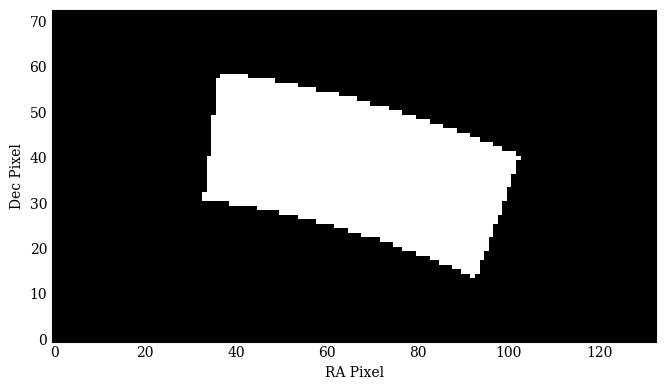

In [101]:
# 将布尔值转换为整数（True -> 1, False -> 0）
mask_image = ra_dec_mask.astype(int)

plt.figure(figsize=(8, 4), dpi=100)
plt.imshow(mask_image.T, origin='lower', cmap='gray')
plt.xlabel('RA Pixel')
plt.ylabel('Dec Pixel')
plt.grid(False)
plt.tight_layout()
plt.show()

In [102]:
n_channels

252

In [104]:
# ====== 不做卷积版本（仅mask + 权重筛选）======
trim_cube = np.zeros_like(og_cube)

for ifreq in trange(252):

    T = og_cube[:, :, ifreq]

    # ===== Create valid mask: 非NaN且非负 =====
    valid_mask = (T >= 0) & np.isfinite(T)

    # ===== 仅保留有效像素 =====
    # 无卷积时，直接使用原值
    T_reconv = T.copy()

    # ===== 应用mask =====
    T_reconv[~ra_dec_mask] = np.nan

    trim_cube[:, :, ifreq] = T_reconv

100%|██████████| 252/252 [00:00<00:00, 13375.74it/s]


In [105]:
# 统计非 NaN 元素个数
non_nan_count = np.sum(~np.isnan(trim_cube))

print(non_nan_count)
total = trim_cube.size
ratio = non_nan_count / total

print(f"非NaN数量: {non_nan_count}")
print(f"占比: {ratio:.6f}")

469980
非NaN数量: 469980
占比: 0.192090


In [106]:
# 统计非 NaN 元素个数
non_nan_count = np.sum(~np.isnan(og_cube))

print(non_nan_count)
total = og_cube.size
ratio = non_nan_count / total

print(f"非NaN数量: {non_nan_count}")
print(f"占比: {ratio:.6f}")

674084
非NaN数量: 674084
占比: 0.275511


In [107]:
# ===== Save result to FITS file =====
output_filename = "data/T_cube_trim.fits" #保存之前想清楚

hdu = fits.PrimaryHDU(data=trim_cube, header=header)
hdu.writeto(output_filename, overwrite=True)
print(f"Result saved to: {output_filename}")

Result saved to: data/T_cube_trim.fits


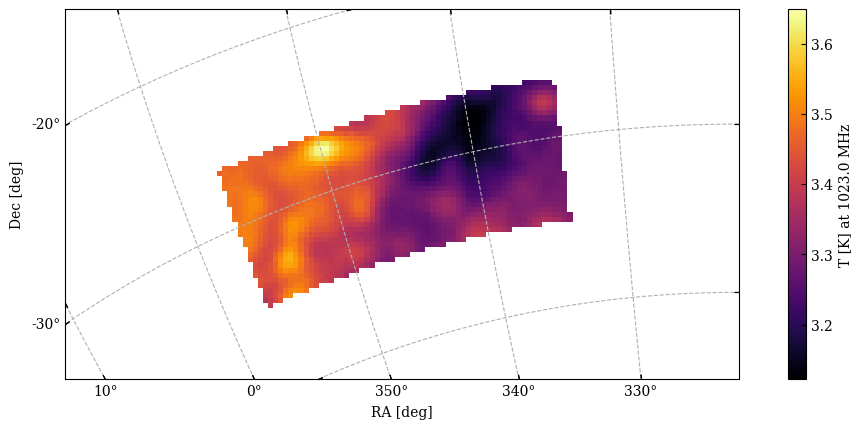

In [108]:
target_freq_mhz = 1023.0  # 目标频率（单位 MHz）

# 查找最接近目标频率的通道索引
channel_index = int(np.argmin(np.abs(freqs - target_freq_mhz)))
selected_freq = freqs[channel_index]

#%% ===== 读取 FITS 数据并构建 WCS =====

with fits.open(output_filename) as hdul:
    output_cube = hdul[0].data
    header = hdul[0].header
    wcs_2d = WCS(header, naxis=2)

#%% ===== 提取目标频率通道的数据 =====

sky_map = output_cube[:, :, channel_index].T  # 转置使图像方向正确

#%% ===== 设置绘图参数并绘制图像 =====

plt.figure(figsize=(10, 4), dpi=100)
ax = plt.subplot(111, projection=wcs_2d)

# 绘图
im = ax.imshow(
    sky_map, origin='lower', cmap='inferno',
)

# 设置坐标格式和标签
ax.coords['ra'].set_format_unit(u.deg)
ax.invert_xaxis()  # 天球图惯例

ax.set_xlabel('RA [deg]')
ax.set_ylabel('Dec [deg]')

# 添加颜色条
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(f'T [K] at {selected_freq:.1f} MHz')

plt.tight_layout()
plt.grid(True)
plt.show()